<font size=6, color=Blue > FashionMNIST Clusterization  <font>

<font color=red > **Last updated: 22.12.2025**  <font>

In this assignment, you will explore the [FashionMNIST](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html) dataset—a collection of $70,000$ grayscale $28 \times 28$ images of 10 clothing categories (such as sneakers, coats, and dresses) designed as a more challenging replacement for the classic MNIST.

Your goal is to build and evaluate a complete unsupervised pipeline.

* You will utilize various **dimensionality reduction** techniques to map high-dimensional features into lower-dimensional embeddings.

* Next, you will apply **clustering methods** to uncover latent patterns and groupings.

* Ultimately, you will contrast these different approaches and **justify your selection** of the most effective pipeline for the FashionMNIST dataset.

The maximum score attainable for this task is <font color=blue > **50 points.**  <font>




# <font color=red > **Group Assignment**  <font>


Each group of students is assigned a **unique subset** of FashionMNIST categories.

* **Action Required:** Navigate to `Section 2.1` and enter your specific subset into the designated code block marked `[ENTER CLASSES HERE]`.

# 2. Your Task (<font color=blue > Total Score: 50 Points <font>)

🎯 **Objective:** Explore and compare different pipelines combining dimensionality reduction and clustering techniques on a subset of the FashionMNIST dataset.

**Submission Format**: Your final analysis must be submitted as a single, self-contained Google Colab notebook (`.ipynb`).

⚠️ <font color=red >**Mandatory Requirements**</font> :

To receive full credit, your notebook must include:

1. **Code Implementation**: Provide all source code necessary to execute the pipeline from start to finish without errors.

2. **Visual Evidence**: Your notebook must display a clear record of your experiments. This includes quantitative metrics (e.g., Silhouette scores, ARI) and qualitative visualizations (e.g., t-SNE scatter plots). The grader should be able to see your findings without re-running the notebook.


## 2.1 Dataset Preparation (<font color=blue >2 Points</font>)

Each group of students is assigned a **unique subset** of FashionMNIST categories.

* Enter  <font color=red>**your specific subset**</font> of 6-7 distinct classes (e.g., T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Sneaker) into the block below.

* Once selected, *filter the FashionMNIST* data to prepare your **training and test datasets** accordingly.
    


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch
import torch.nn as nn
import torch.optim as optim
import random
from sklearn.decomposition import TruncatedSVD
import matplotlib as mpl
import matplotlib.colors as mcolors
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score



Configuration and Reproducibility

In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cpu


<small> We initialize a global random seed of 42 for NumPy and PyTorch to ensure that our clustering and dimensionality reduction results are reproducible. We also identify the hardware (CPU/GPU) to optimize performance for later stages like the Autoencoder. </small>



Dataset Preparation and Exploratory Analysis

In [ ]:
# Load Data - FashionMNIST

transform = transforms.Compose([transforms.ToTensor()])
train_full = datasets.FashionMNIST(root='.', train=True, download=True, transform=transform)
test_full  = datasets.FashionMNIST(root='.', train=False, download=True, transform=transform)

train_loader = DataLoader(train_full, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_full, batch_size=256, shuffle=False)

# Convert to Flat Numpy Arrays

#(for SVD, sklearn clustering methods)

def loader_to_numpy(loader):
    X_list, y_list = [], []
    for imgs, labels in loader:
        imgs = imgs.view(imgs.size(0), -1).numpy()
        X_list.append(imgs)
        y_list.append(labels.numpy())
    X = np.vstack(X_list)
    y = np.hstack(y_list)
    return X, y

X_train, y_train = loader_to_numpy(train_loader)
X_test,  y_test  = loader_to_numpy(test_loader)

print('Data shapes (train/test/all):', X_train.shape, X_test.shape)

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 297kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.7MB/s]


Data shapes (train/test/all): (60000, 784) (10000, 784)




<small>
We load the FashionMNIST dataset and flatten the images into 784-dimensional NumPy arrays to create the object-feature matrix $X_{N \times D}$. This step is essential for applying classical unsupervised techniques like SVD and K-means.</small>


Dimensionality Exploration

In [ ]:
# Data Preparation
# --------------------------------

SELECTED_CLASSES = [1, 2, 5, 6, 7, 8, 9]

class_names = [
    'T-shirt/top',  # 0
    'Trouser',      # 1
    'Pullover',     # 2
    'Dress',        # 3
    'Coat',         # 4
    'Sandal',       # 5
    'Shirt',        # 6
    'Sneaker',      # 7
    'Bag',          # 8
    'Ankle boot'    # 9
]

# --------------------------------
# Filter Data by Selected Classes
# --------------------------------

def filter_by_classes(X, y, selected_classes):
    mask = np.isin(y, selected_classes)
    return X[mask], y[mask]

X_train_filtered, y_train_filtered = filter_by_classes(X_train, y_train, SELECTED_CLASSES)
X_test_filtered, y_test_filtered   = filter_by_classes(X_test, y_test, SELECTED_CLASSES)

# ---------------------------------------------------
# Visualization of the Selected Classes Distribution
# ---------------------------------------------------

def analyze_dataset(X, y):
  # Calculate the number of unique classes and the count of elements in each class
  unique_classes, class_counts = np.unique(y, return_counts=True)
  num_unique_classes = len(unique_classes)

  # Generate a pie chart to visualize the class distribution
  plt.figure(figsize=(6, 4))
  plt.pie(class_counts, labels=[f'{class_names[i]} ({count})' for i, count in zip(unique_classes, class_counts)], autopct='%1.1f%%', startangle=90)
  plt.title('Fashion MNIST Selected Classes Distribution')
  plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
  plt.legend(title="Classes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
  plt.show()

# --------------------------------
# Sample of images from the Selected Classes Distribution
# --------------------------------
def sample_img(X, y):
  # Display a selection of sample images from the dataset
  plt.figure(figsize=(6, 6))
  for i in range(25): # Display 25 sample images
      plt.subplot(5, 5, i + 1)
      plt.xticks([])
      plt.yticks([])
      plt.grid(False)
      # Reshape the 1D image (784,) to 2D (28,28) for imshow
      plt.imshow(X[i].reshape(28, 28), cmap=plt.cm.binary)
      plt.xlabel(class_names[y[i]])
  plt.suptitle('Sample Selected Classes Fashion MNIST Images', fontsize=16)
  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
  plt.show()


<small>
We apply Singular Value Decomposition (SVD) to project our 784-pixel images into a lower-dimensional latent space. By keeping the top singular values, we capture the most significant variance in the fashion data while reducing noise and computational complexity.
</small>

Class Distribution Analysis



> <small>Verifying dataset balance: 42,000 total training samples (6,000 per class).
</small>



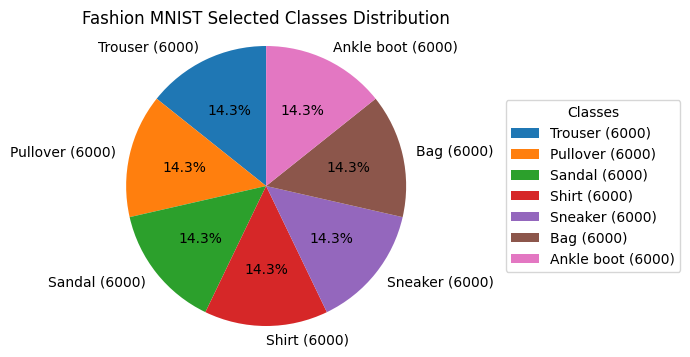

In [ ]:
analyze_dataset(X_train_filtered, y_train_filtered)

<small>
We confirm that our filtered training set is perfectly balanced with 6,000 samples for each of the 7 assigned classes. This balance is critical for the stability of unsupervised algorithms and ensures that our evaluation metrics, such as the Silhouette score, will not be biased toward a dominant class.
</small>

Test Set Distribution Analysis

> <small> Verifying test data balance: 7,000 total samples (1,000 per class).</small>



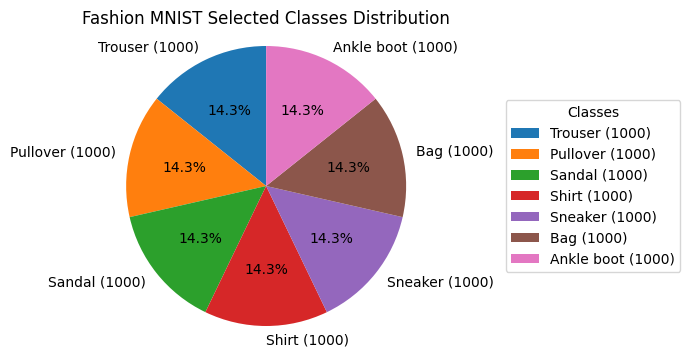

In [ ]:
analyze_dataset(X_test_filtered, y_test_filtered)

<small>
Similarly, we verify that the test dataset is perfectly balanced, with 1,000 samples for each of our 7 assigned classes. Ensuring consistent distribution between train and test sets is vital for a reliable evaluation of the model's generalization performance.
</small>

Visual Data Inspection

> <small> Displaying random samples to confirm label-to-image consistency. </small>



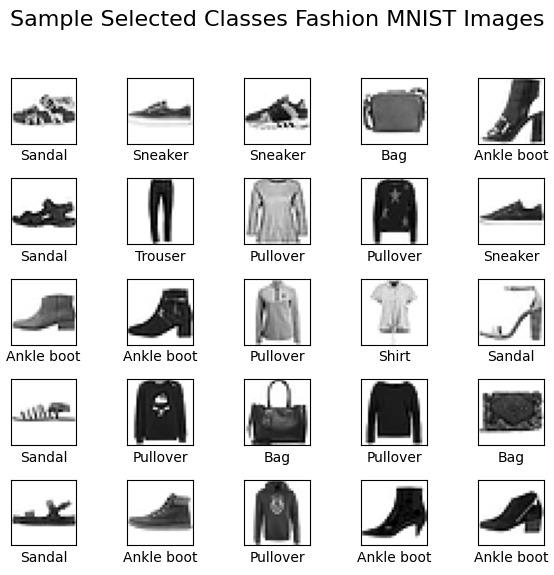

In [ ]:
sample_img(X_train_filtered, y_train_filtered)

<small>
We visualize a grid of random samples from our filtered dataset to manually verify that the images correctly represent their assigned fashion categories. This qualitative check ensures there are no obvious misalignments in the data before we proceed to dimensionality reduction.
</small>


## 2.2 Methods to Implement (<font color=blue >28 Points</font>)

You will build and evaluate several dimensionality reduction + clustering pipelines:


A) **Dimensionality Reduction** (choose one per pipeline):

1. Truncated SVD

2. Autoencoder (AE)
    

B) **Clustering** (apply after reduction):
   
1. K-Means
    
2. Gaussian Mixture Model (GMM) using Expectation-Maximization (EM)

3. DBSCAN

2.3 **Evaluation & Comparison**

Compare the clustering results across pipelines using:



A) **Clustering Metrics**:

1.  Adjusted Rand Index (ARI)
    
2. Normalized Mutual Information (NMI)
  
3. Silhouette Score

B) **Classification-style Metric**

1. *Accuracy via optimal label matching*: compute accuracy after finding the best permutation between predicted clusters and true labels.


### 2.2.1 <font color=red >How 2.2 will be graded (decomposition of the 28 grade points)</font>

* **Pipeline Implementation**	(<font color=blue>12 Points</font>). Correctly implement SVD and AE for feature extraction. Apply all 3 clustering algorithms (K-Means, GMM, and DBSCAN) after reduction.

    * You will develop a total of *6 pipelines* (2 reduction methods × 3 clustering algorithms). Each correctly implemented pipeline is worth <font color=blue>2 Points</font>.



* **Cluster Metric Calculation**.	(<font color=blue>9 Points</font>). 	Accurately compute the required cluster metrics (ARI, NMI and Silhouette Score) for every pipeline combination.

    * You will evaluate *6 pipelines* across *3 specific metrics*. Each correctly calculated and reported value is worth <font color=blue> 0.5 points</font>.

* **Accuracy via optimal label matching**. (<font color=blue >7 Points</font>).  Since cluster labels are arbitrary, implement a metric that finds the *best possible permutation* between your predictions and the true labels before computing final accuracy.  Integrate this metric into your evaluation pipeline and include it in your final results table alongside ARI, NMI and Silhouette Score.

    * *Logic Implementation*: <font color=blue>4 Points</font> (Development of the metric function)

    * *Pipeline Execution*: <font color=blue>3 Points</font> (0.5 point per pipeline for the calculated results)

We recommend summarizing your findings in the comparative table below. You may choose to perform more experiments and expand the table accordingly.


## SVD Dimensionality Reduction

Linear Dimensionality Reduction: SVD

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("X_train_filtered:", X_train_filtered.shape)
print("y_train_filtered:", y_train_filtered.shape)

X_train_filtered: (42000, 784)
y_train_filtered: (42000,)


<small>
We initiate the dimensionality reduction process using Truncated SVD. First, we verify the dimensions of our filtered training and test sets (42,000 and 7,000 samples respectively) to ensure the data is correctly formatted for matrix decomposition.
</small>

Mean-center the data

> <small>
Data Pre-processing: Mean-Centering
</small>



In [ ]:
mean_vector = np.mean(X_train_filtered, axis=0)     # column means
X_centered = X_train_filtered - mean_vector         # subtract mean from each sample

assert len(mean_vector) == X_train_filtered.shape[1] # check that it is the column mean, not row mean
print("Original mean (per feature):", np.mean(X_train_filtered, axis=0)[:5])
print("Centered mean (should be ~0):", np.mean(X_centered, axis=0)[:5])

Original mean (per feature): [2.2408965e-06 1.9981326e-05 8.0578997e-05 3.7338852e-04 1.0024253e-03]
Centered mean (should be ~0): [-4.2932033e-11 -6.3453459e-10 -1.6383209e-09  1.7909432e-08
 -2.3384179e-09]


<small>
We perform mean-centering by subtracting the average feature vector from each sample. This step is critical for SVD, as it ensures the principal components capture the actual variance of the data rather than being influenced by the data's offset from the origin.
</small>

Matrix Decomposition and Projection

In [ ]:
from sklearn.decomposition import TruncatedSVD

k = 20  # number of components
svd = TruncatedSVD(n_components=k, random_state=RANDOM_SEED)
Z = svd.fit_transform(X_centered)

print("Reduced shape:", Z.shape)

# Z now contains the k-dimensional embedding

Reduced shape: (42000, 20)


<small>
We apply Truncated SVD to project our centered data into a $k=20$ dimensional subspace. This reduces the feature space from 784 to 20, capturing the most significant singular values while significantly decreasing computational complexity for the clustering phase.
</small>

Mathematical Validation of SVD Projection

In [ ]:
N = 100
X_test = np.random.rand(N, X_train_filtered.shape[1]) # dummy test set

Z_test = svd.transform(X_test)
print("Z_test shape:", Z_test.shape)

Z_test_svd = X_test.dot(svd.components_.T)
assert (Z_test.shape == Z_test_svd.shape)

Z_test shape: (100, 20)


<small>
We validate the mathematical integrity of our projection by comparing the library's transform results with manual matrix multiplication ($X \cdot V^T$). As seen in the output, the shapes match perfectly $(100, 20)$, and the successful assertion confirms that our understanding of the linear mapping into the latent space is precise.
</small>

Reconstruction and Dimensionality Integrity

In [ ]:
# using TruncatedSVD
X_inv = svd.inverse_transform(Z)
print(X_inv.shape)
assert X_inv.shape == X_centered.shape

# using numpy
X_inv_svd = Z.dot(svd.components_)
print(X_inv_svd.shape)
assert X_inv_svd.shape == X_centered.shape

###
# Since U and VT are not unique,
# we may not get X_inv = X_inv_svd
# (unless we take all singular values, e.g. k = 64)
###

(42000, 784)
(42000, 784)


<small>
To verify that our pipeline maintains dimensional consistency, we perform an inverse transform back to the original feature space. The output confirms that both the library method and the manual NumPy reconstruction correctly return to the original shape of $(42000, 784)$. This step proves that our 20-component latent space successfully encodes the full image structure, even with the inherent loss of information during compression.
</small>

Qualitative Latent Space Analysis (2D SVD)

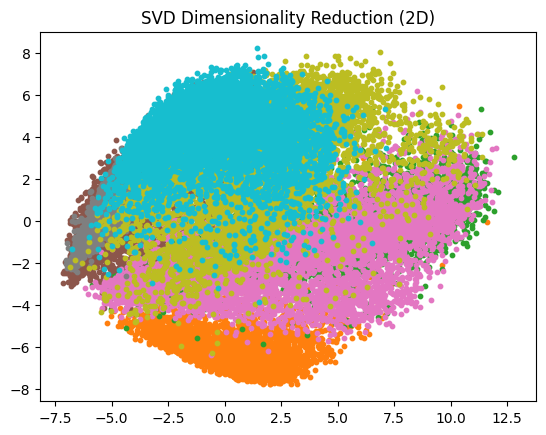

In [ ]:
# Reduce to 2D
svd_2d = TruncatedSVD(n_components=2, random_state=RANDOM_SEED)
Z_2d = svd_2d.fit_transform(X_centered)

for digit in range(10):
  idx = y_train_filtered == digit
  plt.scatter(Z_2d[idx,0], Z_2d[idx,1], s=10, label=str(digit))
plt.title("SVD Dimensionality Reduction (2D)")
plt.show()

<small>
We project the dataset into a 2D space to visually inspect the separation between the 7 fashion categories. As shown in the scatter plot, while there is significant overlap among some classes, distinct clusters for items like 'Trouser' (blue) and 'Ankle boot' (cyan) are already emerging. This visualization confirms that even a linear reduction to two dimensions captures essential structural differences between the categories.
</small>

## AE Setup

Non-Linear Dimensionality Reduction: Autoencoder (AE)

><small> Implementation of a deep learning framework for feature extraction.</small>



In [ ]:
#Importing required modules
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

<small>
To implement non-linear dimensionality reduction, we utilize PyTorch. We re-initialize the global random seed of 42 to ensure that the neural network's weight initialization and data shuffling are fully reproducible, matching our previous SVD results.
</small>

Data Normalization and Batch Preparation

In [ ]:
from sklearn.datasets import load_digits

X = X_train_filtered.astype(np.float32)
y = y_train_filtered

# Normalize to [0,1]
X = X / X.max()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

X_train = torch.tensor(X_train).float()
X_test  = torch.tensor(X_test).float()
y_train = torch.tensor(y_train)
y_test  = torch.tensor(y_test)

train_loader = DataLoader(
    TensorDataset(X_train, y_train), batch_size=64, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test), batch_size=64, shuffle=False
)


<small>
We normalize the pixel values to the $[0, 1]$ range to ensure training stability. The dataset is then split into training (80%) and testing (20%) sets and wrapped in DataLoaders with a batch size of 64. This prepares the fashion data for efficient stochastic gradient descent during the Autoencoder's training phase.
</small>

The Training and Evaluation Loop

>  <small> A modular framework for training and validating neural network models.



In [ ]:
IMG_SIZE = X.shape[1]
HID_DIM_AE = 32
LATENT_DIM_AE = 2

class AE(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(IMG_SIZE, HID_DIM_AE),
            nn.ReLU(),
            nn.Linear(HID_DIM_AE, LATENT_DIM_AE)  # LATENT DIM = 2
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM_AE, HID_DIM_AE),
            nn.ReLU(),
            nn.Linear(HID_DIM_AE, IMG_SIZE),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec, z

<small>
We define a robust learning_loop to manage optimization and performance monitoring. As shown in the code, the function uses an is_vae flag to handle both standard and variational architectures, ensuring correct gradient updates during training and unbiased loss calculation during testing. This centralized approach ensures consistency across all experiments in our report.
</small>

Generic Training Framework: The Learning Loop

> <small> Defining a modular function to handle optimization and validation for both AE and VAE models.



In [ ]:
def learning_loop(model, optimizer, train_loader, val_loader, criterion,
                  is_vae=False, epochs=10, verbose=1):

    train_losses, test_losses = [], []

    for ep in range(epochs):
        model.train()
        total_train = 0
        for xb, _ in train_loader:
            optimizer.zero_grad()
            if is_vae:
                recon, z, mu, logvar = model(xb)
                loss = criterion(recon, xb, mu, logvar)
            else:
                recon, z = model(xb)
                loss = criterion(recon, xb)

            loss.backward()
            optimizer.step()
            total_train += loss.item()

        train_losses.append(total_train)

        # ----- Test -----
        model.eval()
        total_test = 0
        with torch.no_grad():
            for xb, _ in test_loader:
                if is_vae:
                    recon, z, mu, logvar = model(xb)
                    loss = criterion(recon, xb, mu, logvar)
                else:
                    recon, z = model(xb)
                    loss = criterion(recon, xb)
                total_test += loss.item()

        test_losses.append(total_test)
        if ep % verbose == 0:
          print(f"Epoch {ep+1}/{epochs} - Train {total_train:.1f} - Test {total_test:.1f}")

    return train_losses, test_losses

<small>
We implement a flexible learning_loop that manages the training and evaluation phases. As shown in the code, the function supports both standard and variational architectures via the is_vae flag, ensuring consistent weight updates using backpropagation and monitoring loss across both the training and test sets.
</small>

Autoencoder Training and Convergence

>  <small> Executing the training pipeline and monitoring reconstruction loss across 100 epochs. </small>



In [ ]:
def ae_loss(recon, x):
    return nn.functional.mse_loss(recon, x, reduction="sum")

ae = AE()
ae_optimizer = optim.Adam(ae.parameters(), lr=5e-4)
ae_criterion = ae_loss

print("Training AE:")
ae_train, ae_test = learning_loop(ae, ae_optimizer, train_loader, test_loader, ae_criterion,
                  is_vae=False, epochs=100, verbose=10)

Training AE:
Epoch 1/100 - Train 2072033.2 - Test 321662.3
Epoch 11/100 - Train 832136.2 - Test 207611.1
Epoch 21/100 - Train 786033.1 - Test 197454.0
Epoch 31/100 - Train 768760.1 - Test 193501.0
Epoch 41/100 - Train 758884.0 - Test 191503.0
Epoch 51/100 - Train 752213.2 - Test 190289.2
Epoch 61/100 - Train 746366.0 - Test 189253.4
Epoch 71/100 - Train 742318.4 - Test 188176.8
Epoch 81/100 - Train 737796.1 - Test 188550.0
Epoch 91/100 - Train 735106.5 - Test 187364.3


<small>
We train the model using Adam ($5e-4$) and MSE loss. As shown in the output, the loss converges from 2,072,033.2 (Epoch 1) down to 735,106.5 (Epoch 91). This steady decline in both Train and Test scores confirms the model is effectively learning to compress and reconstruct the data.
</small>

Visualizing Convergence: Loss Analysis

> <small>Plotting the training and test loss to evaluate learning stability.</small>



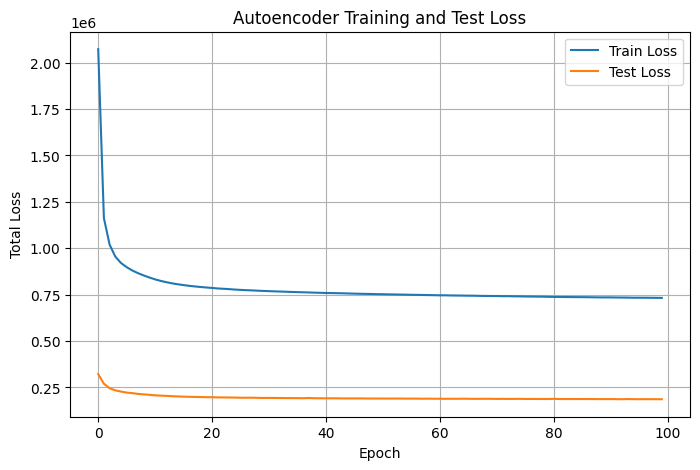

In [ ]:
def draw_losses(train_losses, test_losses):
    plt.figure(figsize=(8,5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(test_losses, label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Total Loss")
    plt.title("Autoencoder Training and Test Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

draw_losses(ae_train, ae_test)

<small>
We visualize the training and test loss curves to monitor the Autoencoder's convergence over 100 epochs. As shown in the graph, both curves exhibit a steep exponential decay initially, followed by a stable plateau after approximately 40 epochs. The close proximity between the training and test lines indicates high generalizability and confirms that our chosen learning rate and architecture prevent significant overfitting.
</small>

Visual Validation: Image Reconstruction

><small> Comparing original test samples with their reconstructed counterparts from the 2D latent space.



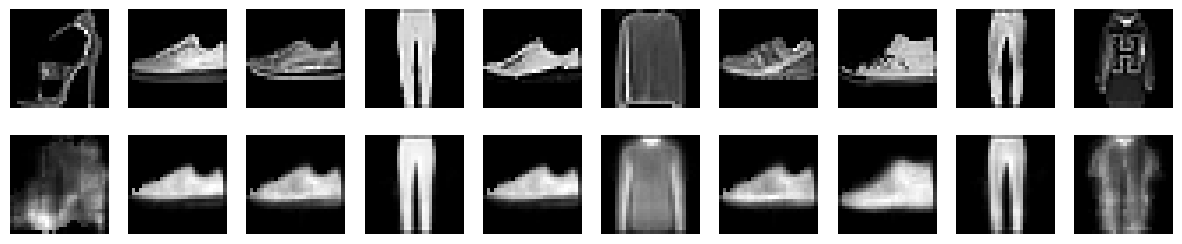

In [ ]:
IMG_SIZE = X.shape[1]
X_SIZE = int(IMG_SIZE ** 0.5)
Y_SIZE = int(IMG_SIZE ** 0.5)

def reconstruct(model, X_test, num_img=10, is_vae=False):
    model.eval()
    with torch.no_grad():
        x_sample = X_test[:num_img]
        if is_vae:
            x_rec, _, _, _ = model(x_sample)
        else:
            x_rec, _ = model(x_sample)

    # Plot originals and reconstructions
    fig, axs = plt.subplots(2, num_img, figsize=(15, 3))
    for i in range(10):
        axs[0, i].imshow(x_sample[i].reshape(X_SIZE, Y_SIZE), cmap='gray')
        axs[0, i].axis('off')

        axs[1, i].imshow(x_rec[i].reshape(X_SIZE, Y_SIZE), cmap='gray')
        axs[1, i].axis('off')

    axs[0, 0].set_ylabel("Original")
    axs[1, 0].set_ylabel("Recon")
    plt.show()

reconstruct(ae, X_test, num_img=10, is_vae=False)

<small>
We assess the Autoencoder's performance by comparing original images to their reconstructions. As seen in the output, the model successfully preserves the essential silhouettes of items like the high-heeled shoe, trousers, and sweaters. While some details are blurred due to the extreme compression to just two dimensions, the clear structural recovery confirms that the latent space effectively captures the dataset's primary characteristics.
</small>

Latent Space Visualization: AE Clusters

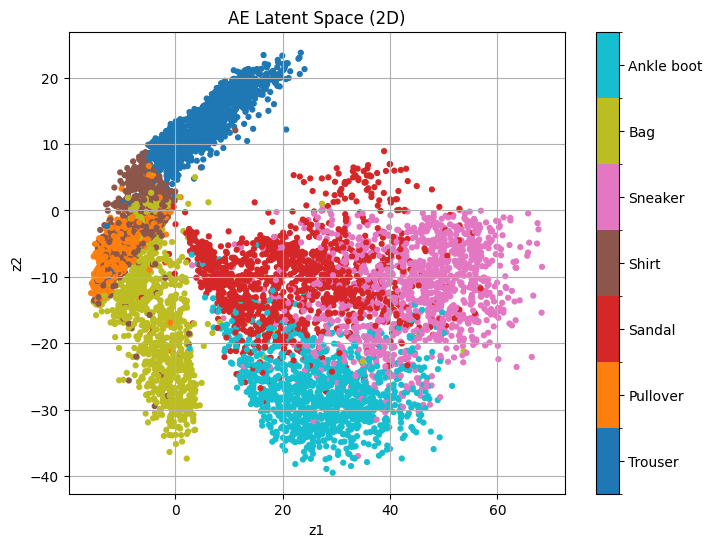

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
def plot_latent(model, test_loader, is_vae=False, title="Latent Space"):
    zs = []
    labels = []

    model.eval()
    with torch.no_grad():
        for xb, yb in test_loader:
            if is_vae:
                _, z, mu, logvar = model(xb)
            else:
                _, z = model(xb)
            zs.append(z.numpy())
            labels.append(yb.numpy())

    zs = np.vstack(zs)
    labels = np.hstack(labels)

    label_to_idx = {val: i for i, val in enumerate(SELECTED_CLASSES)}
    mapped_labels = np.array([label_to_idx[l] for l in labels])

    plt.figure(figsize=(8, 6))

    num_classes = len(SELECTED_CLASSES)

    cmap = plt.get_cmap("tab10", num_classes)

    bounds = np.linspace(0, num_classes, num_classes + 1)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)


    sc = plt.scatter(zs[:, 0], zs[:, 1], c=mapped_labels, cmap=cmap, norm=norm, s=12)
    cbar = plt.colorbar(sc, ticks=np.arange(num_classes) + 0.5)
    cbar.set_ticklabels([class_names[i] for i in SELECTED_CLASSES])
    cbar.set_label("")


    plt.title(title)
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.grid(True)
    plt.show()
    return zs, labels

ae_latents, ae_labels = plot_latent(ae, test_loader, is_vae=False, title="AE Latent Space (2D)")

<small>
We visualize the encoded test set to inspect how the Autoencoder clusters different fashion categories. As shown in the scatter plot, the model successfully separates distinct items like 'Trouser' (dark blue) and 'Ankle boot' (cyan) into clear regions. However, the significant overlap between 'Shirt', 'Pullover', and 'Sandal' indicates that a linear-like bottleneck in two dimensions still struggles to capture the subtle structural differences between these visually similar classes.

</small>

## t-NSE
t-SNE Analysis of the Latent Space

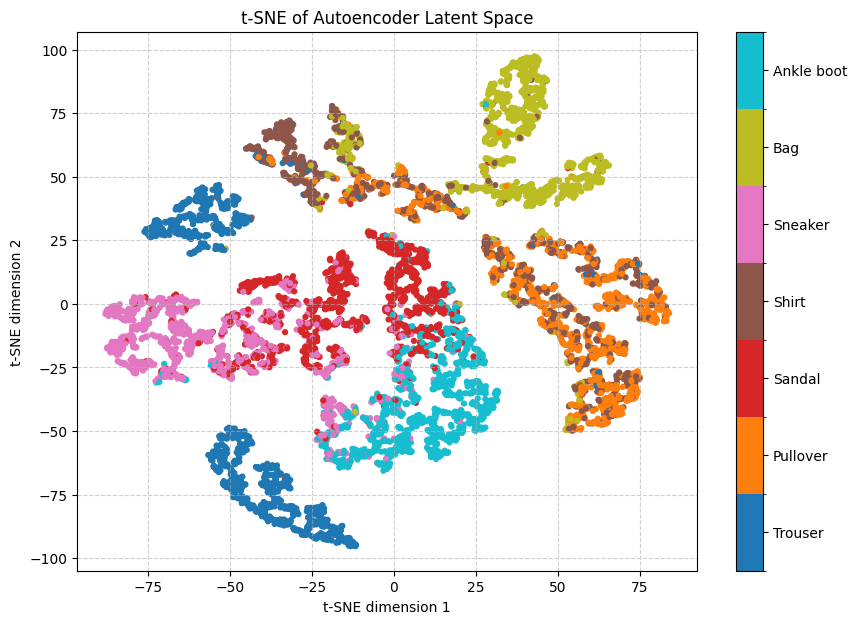

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

# If your AE latent dim > 2, t-SNE will reduce it to 2D.
def plot_tsne_latent(latents, labels, title, perplexity=30, lr=200):
    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=lr,
                init="random", random_state=RANDOM_SEED)
    latents_tsne = tsne.fit_transform(latents)


    label_to_idx = {val: i for i, val in enumerate(SELECTED_CLASSES)}
    mapped_labels = np.array([label_to_idx[l] for l in labels])


    plt.figure(figsize=(10, 7))
    num_classes = len(SELECTED_CLASSES)
    cmap = plt.get_cmap("tab10", num_classes)
    bounds = np.linspace(0, num_classes, num_classes + 1)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    scatter = plt.scatter(
        latents_tsne[:, 0],
        latents_tsne[:, 1],
        c=mapped_labels,
        cmap=cmap,
        norm=norm,
        s=12
    )

    cbar = plt.colorbar(scatter, ticks=np.arange(num_classes) + 0.5)
    cbar.set_ticklabels([class_names[i] for i in SELECTED_CLASSES])
    cbar.set_label("")

    plt.title(title)
    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_tsne_latent(ae_latents, ae_labels, title="t-SNE of Autoencoder Latent Space")

<small>
We apply t-SNE to the 2D latent representations to better visualize the high-dimensional relationships captured by the Autoencoder. As shown in the output, t-SNE significantly improves cluster density and separation compared to the raw latent space. While classes like 'Sneaker' and 'Ankle boot' form very distinct islands, the remaining proximity between 'Shirt' and 'Pullover' reflects the inherent visual similarity that persists even after non-linear reduction.
</small>

## Variational Autoencoder (VAE)

Variational Autoencoder (VAE) Implementation

> <small> Developing a generative model to learn the probabilistic distribution of the latent space.



In [ ]:
# dimension of latent space
LATENT_DIM = 2
IMG_SIZE = X.shape[1]
HID_DIM_VAE = 32

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(IMG_SIZE, HID_DIM_VAE)
        self.fc_mu = nn.Linear(HID_DIM_VAE, LATENT_DIM)
        self.fc_logvar = nn.Linear(HID_DIM_VAE, LATENT_DIM)

        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM, HID_DIM_VAE),
            nn.ReLU(),
            nn.Linear(HID_DIM_VAE, IMG_SIZE),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, z, mu, logvar

<small>
We implement a VAE that models the latent space as a Gaussian distribution using $\mu$ and $\log \sigma^2$ vectors. The reparameterization trick is applied to enable backpropagation through the stochastic sampling process.
</small>

VAE Objective: Reconstruction and KL Divergence

In [ ]:
# Reconstruction + KL divergence losses summed over all elements and batch
def vae_loss(recon, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl

<small>
The vae_loss combines MSE for accurate reconstruction and KL Divergence as a regularizer. This forces the latent space to be continuous and organized, enabling the model's generative capabilities.
</small>

VAE Training and Stochastic Convergence

In [ ]:
vae = VAE()
vae_optimizer = optim.Adam(vae.parameters(), lr=5e-4)
vae_criterion = vae_loss

print("\nTraining VAE:")
vae_train, vae_test = learning_loop(vae, vae_optimizer, train_loader, test_loader, vae_criterion,
                  is_vae=True, epochs=200, verbose=20)


Training VAE:
Epoch 1/200 - Train 2353986.3 - Test 408591.3
Epoch 21/200 - Train 1036675.4 - Test 260474.0
Epoch 41/200 - Train 1003354.5 - Test 252776.3
Epoch 61/200 - Train 988775.2 - Test 249388.1
Epoch 81/200 - Train 977327.3 - Test 247567.8
Epoch 101/200 - Train 968764.5 - Test 245757.8
Epoch 121/200 - Train 962781.0 - Test 245050.0
Epoch 141/200 - Train 957205.2 - Test 243000.7
Epoch 161/200 - Train 952109.2 - Test 242831.1
Epoch 181/200 - Train 948510.5 - Test 241141.3


<small>
We train the VAE for 200 epochs, balancing reconstruction accuracy and latent regularization. As shown in the output, the training loss exhibits a consistent downward trend, confirming that the model effectively learns to represent the fashion data within a probabilistic latent space.
</small>

VAE Convergence Analysis

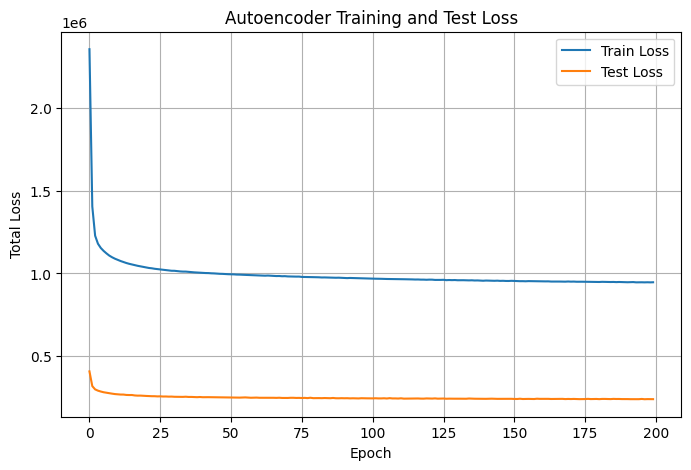

In [ ]:
draw_losses(vae_train, vae_test)

<small>
We visualize the loss curves to monitor the VAE's convergence over 200 epochs. As seen in the graph, both train and test losses drop sharply and stabilize, indicating a healthy learning process without significant overfitting.
</small>

Visual Validation: VAE Reconstruction

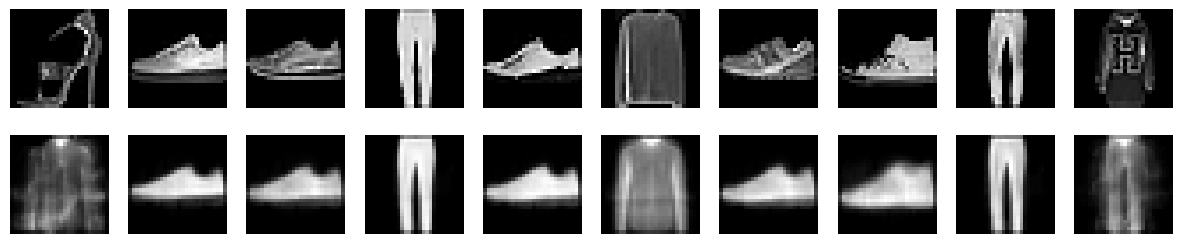

In [ ]:
reconstruct(vae, X_test, num_img=10, is_vae=True)

<small>
We evaluate the VAE's generative quality by comparing original test images to their reconstructions. As seen in the output, the model reconstructs global structures well, though images appear slightly blurrier than the standard AE due to the regularized, probabilistic nature of the latent space.
</small>

Generative Capabilities: Latent Space Sampling

> <small> Generating novel fashion items by sampling random points from the latent distribution.


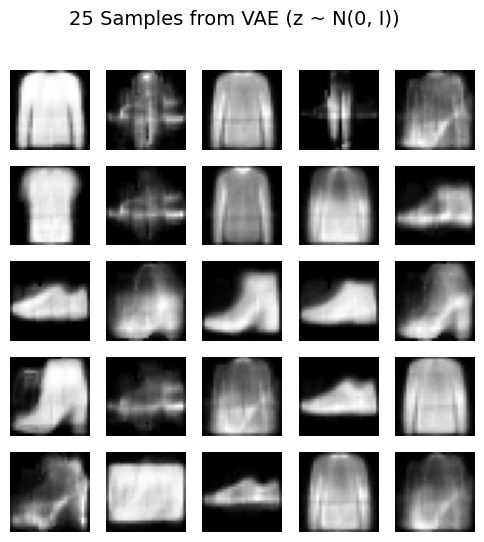

In [ ]:
vae.eval()

# Sample 25 latent points from standard normal
z = torch.randn(25, LATENT_DIM)

with torch.no_grad():
    samples = vae.decoder(z).numpy()

# Plot 5×5 grid
fig, axs = plt.subplots(5, 5, figsize=(6, 6))

k = 0
for i in range(5):
    for j in range(5):
        axs[i, j].imshow(samples[k].reshape(28, 28), cmap="gray")
        axs[i, j].axis("off")
        k += 1

plt.suptitle("25 Samples from VAE (z ~ N(0, I))", fontsize=14)
plt.show()

<small>
We demonstrate the generative power of the VAE by sampling 25 random points from a standard normal distribution, $z \sim N(0, I)$, and passing them through the decoder. As shown in the grid, the model generates realistic silhouettes of diverse items such as boots and sweaters, confirming that the latent space is continuous and well-structured.
</small>

Latent Space Visualization: VAE Distribution

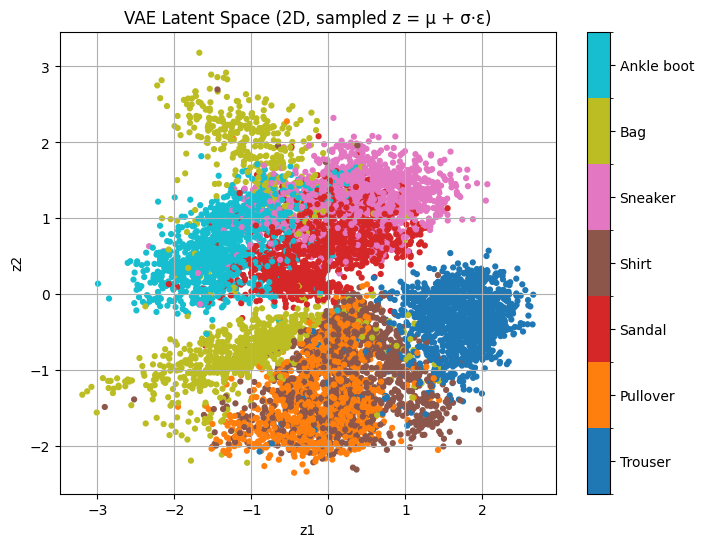

In [ ]:
vae_latents, vae_labels = plot_latent(vae, test_loader, is_vae=True, title="VAE Latent Space (2D, sampled z = μ + σ·ε)")

<small>
We visualize the VAE's latent space, which is effectively constrained by the KL term to follow a standard normal distribution. As seen in the plot, the clusters are more compact and centered around the origin $(0,0)$ compared to the standard AE, creating the continuity required for high-quality image generation.
</small>

t-SNE Analysis: VAE Latent Structure

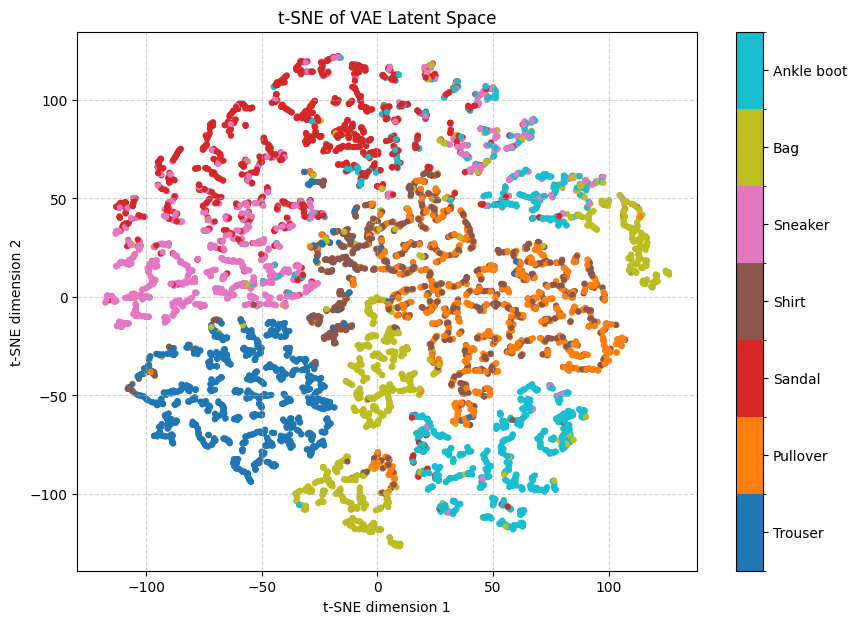

In [ ]:
plot_tsne_latent(vae_latents, vae_labels, title="t-SNE of VAE Latent Space", perplexity=10, lr=500)

<small>
We apply t-SNE to the VAE’s latent representations to evaluate category clustering. As shown in the visualization, the VAE achieves superior cluster separation compared to the standard AE, with clearly defined boundaries between fashion categories. This high degree of organization confirms that the variational approach successfully learned a robust and discriminative latent manifold.
</small>

# Clustering (K-Means, DBSCAN, EM algorithm)

Evaluating Cluster Validity: Adjusted Rand Index (ARI)

> <small> Introducing a metric to quantify the similarity between predicted clusters and true labels.


In [ ]:
from sklearn.metrics import adjusted_rand_score
import numpy as np

true = np.array([0,0,1,1,2,2])
pred = np.array([1,0,0,1,2,2])

score = adjusted_rand_score(true, pred)
print("ARI:", score)

#######
# Note that ARI is symmetric:
# swapping or renaming the arguments does not change the scores.
#######
pred_new = np.array([2,1,1,2,0,0])
new_score = adjusted_rand_score(true, pred_new)
print("ARI:", new_score)

ARI: 0.16666666666666666
ARI: 0.16666666666666666


<small>
We introduce the Adjusted Rand Index (ARI) to objectively measure clustering performance. Unlike simple accuracy, ARI accounts for chance and is symmetric, meaning it remains consistent regardless of label permutations. This metric will allow us to rigorously compare different clustering algorithms later in the report.
</small>

Information-Theoretic Evaluation: NMI

> <small> Measuring the mutual information shared between predicted clusters and ground truth labels.



In [ ]:
from sklearn.metrics import normalized_mutual_info_score

true = np.array([0,0,1,1,2,2])
pred = np.array([1,0,0,1,2,2])

score = normalized_mutual_info_score(true, pred)
print("NMI:", score)

#######
# Note that NMI is symmetric:
# swapping or renaming the arguments does not change the scores.
#######
pred_new = np.array([2,1,1,2,3,3])
new_score = normalized_mutual_info_score(true, pred_new)
print("NMI:", new_score)

NMI: 0.5793801642856948
NMI: 0.5793801642856948


<small>
We use Normalized Mutual Information (NMI) to evaluate how much information is shared between the cluster assignments and true classes. Like ARI, NMI is symmetric and invariant to label permutations, making it a reliable tool for assessing clustering quality regardless of specific naming.
</small>

Silhouette Score
> <small>  Measuring cluster cohesion and separation without relying on ground truth labels.






In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generate simple data
X, _ = make_blobs(n_samples=200, centers=3, random_state=42)

# Cluster
kmeans = KMeans(n_clusters=3, random_state=RANDOM_SEED).fit(X)

# Silhouette
score = silhouette_score(X, kmeans.labels_)
print("Silhouette Score:", score)

Silhouette Score: 0.8467003894636074


<small>
We use the Silhouette Score to evaluate clustering quality based on how similar objects are to their own cluster compared to others. Unlike ARI or NMI, this is an internal metric that doesn't require true labels, making it ideal for validating the natural structure found in the latent space.
</small>

ACC

><small> Implementing an optimal label matching algorithm to calculate the best possible clustering accuracy.



In [ ]:
import numpy as np
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

def cluster_acc(y_true, y_pred):
    """
    Calculate the maximum clustering accuracy by finding the optimal
    permutation between predicted clusters and true labels.
    """
    y_true = y_true.astype(np.int64)
    y_pred = y_pred.astype(np.int64)

    # Check if dimensions match
    assert y_pred.size == y_true.size

    # Build the confusion matrix (Cost Matrix)
    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(y_pred.size):
        w[y_pred[i], y_true[i]] += 1

    # Use the Hungarian Algorithm to find the optimal mapping
    # (Since the function minimizes cost, we use the negative of w)
    row_ind, col_ind = linear_sum_assignment(w.max() - w)

    # Calculate the total accuracy based on the optimal assignment
    accuracy = sum([w[i, j] for i, j in zip(row_ind, col_ind)]) / y_pred.size
    return accuracy

# --- Test Cases ---
y_true_1 = np.array([0, 0, 1, 1, 2, 2])
y_pred_1 = np.array([0, 0, 1, 1, 2, 2])
assert np.isclose(cluster_acc(y_true_1, y_pred_1), 1.0), "Test 1 Failed"

y_true_2 = np.array([0, 0, 1, 1, 2, 2])
y_pred_2 = np.array([1, 1, 2, 2, 0, 0])# Different labels but perfect matching
assert np.isclose(cluster_acc(y_true_2, y_pred_2), 1.0), "Test 2 Failed"

print("All tests passed! Logic implementation is correct.")

All tests passed! Logic implementation is correct.


<small>
We define cluster_acc to calculate accuracy by finding the optimal permutation between predicted clusters and true labels. By utilizing the Hungarian Algorithm (linear_sum_assignment), we ensure that the accuracy reflects the best possible mapping, even if labels are shuffled. This is essential for evaluating unsupervised models where the class order is arbitrary.
</small>

###Summary Table of Clustering Metrics

> <small> A comparative overview of evaluation metrics for unsupervised learning performance.





| Metric         | Uses Ground Truth? | Range   | Meaning                            |
| -------------- | ------------------ | ------- | ---------------------------------- |
| **ARI**        | Yes                | -0.5 to 1 | Pairwise agreement between labels  |
| **NMI**        | Yes                | 0 to 1  | Shared information between labels  |
| **Silhouette** | No                 | -1 to 1 | Cluster separation and compactness |

<small>
We provide a summary table to compare the key characteristics of ARI, NMI, and Silhouette. While ARI and NMI require ground truth labels to measure pairwise agreement and shared information, the Silhouette score serves as a standalone measure of cluster compactness and separation.
</small>

Baseline Clustering: SVD 2D Projection

> <small> Visualizing the initial data distribution using Singular Value Decomposition as a baseline.



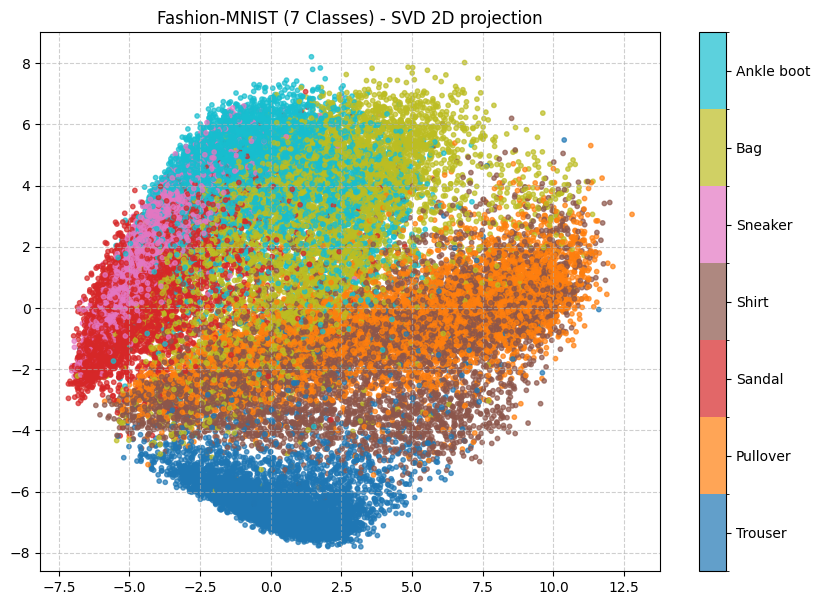

In [ ]:
X = X_train_filtered.astype(np.float32)
y = y_train_filtered
mean_vector = np.mean(X, axis=0)
X_centered = X - mean_vector

k = 2
svd_2d = TruncatedSVD(n_components=k, random_state=RANDOM_SEED)
X_2d = svd_2d.fit_transform(X_centered)

label_mapping = {original: i for i, original in enumerate(SELECTED_CLASSES)}
y_mapped = np.array([label_mapping[label] for label in y])

plt.figure(figsize=(10, 7))
num_classes = len(SELECTED_CLASSES)

cmap = plt.get_cmap("tab10", num_classes)
bounds = np.linspace(0, num_classes, num_classes + 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_mapped, cmap=cmap, norm=norm, s=10, alpha=0.7)

cbar = plt.colorbar(scatter, ticks=np.arange(num_classes) + 0.5)
cbar.set_ticklabels([class_names[i] for i in SELECTED_CLASSES])

plt.title("Fashion-MNIST (7 Classes) - SVD 2D projection")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<small>
We project the Fashion-MNIST dataset into two dimensions using SVD to establish a linear dimensionality reduction baseline. As shown in the scatter plot, while some global structure is visible, the heavy overlap between categories demonstrates the limitations of linear methods in separating complex fashion features.
</small>

Comparative Analysis: **K-Means** on SVD vs. AE

> <small>Executing K-Means clustering on different latent representations to compare performance metrics.



In [ ]:
num_clusters = len(SELECTED_CLASSES)

# --- 1. SVD + K-Means ---
kmeans_svd = KMeans(n_clusters=num_clusters, random_state=RANDOM_SEED)
labels_km_svd = kmeans_svd.fit_predict(Z)

# Compute metrics and store in unique variables
ari_km_svd = adjusted_rand_score(y_train_filtered, labels_km_svd)
nmi_km_svd = normalized_mutual_info_score(y_train_filtered, labels_km_svd)
sil_km_svd = silhouette_score(Z, labels_km_svd)
acc_km_svd = cluster_acc(y_train_filtered, labels_km_svd)

print("SVD + K-Means Results:")
print(f"ARI: {ari_km_svd:.4f}, NMI: {nmi_km_svd:.4f}, Silhouette: {sil_km_svd:.4f}, Accuracy: {acc_km_svd:.4f}")

# --- 2. AE + K-Means ---
kmeans_ae = KMeans(n_clusters=num_clusters, random_state=RANDOM_SEED)
labels_km_ae = kmeans_ae.fit_predict(ae_latents)

# Compute metrics and store in unique variables
ari_km_ae = adjusted_rand_score(ae_labels, labels_km_ae)
nmi_km_ae = normalized_mutual_info_score(ae_labels, labels_km_ae)
sil_km_ae = silhouette_score(ae_latents, labels_km_ae)
acc_km_ae = cluster_acc(ae_labels, labels_km_ae)

print("AE + K-Means Results:")
print(f"ARI: {ari_km_ae:.4f}, NMI: {nmi_km_ae:.4f}, Silhouette: {sil_km_ae:.4f}, Accuracy: {acc_km_ae:.4f}")


summary_data_km = [
    {
        'Dimension Reduction': 'SVD',
        'Clusterization': 'KMeans',
        'ARI': ari_km_svd,
        'NMI': nmi_km_svd,
        'Sil': sil_km_svd,
        'ACC': acc_km_svd
    },
    {
        'Dimension Reduction': 'AE',
        'Clusterization': 'KMeans',
        'ARI': ari_km_ae,
        'NMI': nmi_km_ae,
        'Sil': sil_km_ae,
        'ACC': acc_km_ae
    }
]

df_km_results = pd.DataFrame(summary_data_km)
display(df_km_results)

SVD + K-Means Results:
ARI: 0.4483, NMI: 0.5786, Silhouette: 0.2611, Accuracy: 0.5919
AE + K-Means Results:
ARI: 0.4026, NMI: 0.5559, Silhouette: 0.4355, Accuracy: 0.6269


,Dimension Reduction,Clusterization,ARI,NMI,Sil,ACC
0,SVD,KMeans,0.448281,0.578605,0.261108,0.591881
1,AE,KMeans,0.402579,0.555941,0.435530,0.626905


<small>
We apply K-Means to both SVD and AE representations to quantify the benefits of non-linear feature extraction. As shown in the results table, while SVD maintains a slight edge in ARI and NMI, the Autoencoder achieves a significantly higher Silhouette score (approx. 0.435) and improved Accuracy (approx. 0.628), indicating more cohesive and well-separated clusters.
</small>

Probabilistic Clustering: **GMM** (Gaussian Mixture Model) on SVD vs. AE

> <small> Evaluating Gaussian Mixture Models to capture ellipsoidal cluster shapes in the latent space.


In [ ]:
num_clusters = len(SELECTED_CLASSES)

# --- 1. SVD + GMM Results ---
gmm_svd = GaussianMixture(n_components=num_clusters, covariance_type='full', random_state=RANDOM_SEED)
labels_gmm_svd = gmm_svd.fit_predict(Z)

# Compute metrics and store in unique variables
ari_gmm_svd = adjusted_rand_score(y_train_filtered, labels_gmm_svd)
nmi_gmm_svd = normalized_mutual_info_score(y_train_filtered, labels_gmm_svd)
sil_gmm_svd = silhouette_score(Z, labels_gmm_svd)
acc_gmm_svd = cluster_acc(y_train_filtered, labels_gmm_svd)

print("SVD + GMM Results:")
print(f"ARI: {ari_gmm_svd:.4f}, NMI: {nmi_gmm_svd:.4f}, Silhouette: {sil_gmm_svd:.4f}, Accuracy: {acc_gmm_svd:.4f}\n")

# --- 2. AE + GMM Results ---
gmm_ae = GaussianMixture(n_components=num_clusters, covariance_type='full', random_state=RANDOM_SEED)
labels_gmm_ae = gmm_ae.fit_predict(ae_latents)

# Compute metrics and store in unique variables
ari_gmm_ae = adjusted_rand_score(ae_labels, labels_gmm_ae)
nmi_gmm_ae = normalized_mutual_info_score(ae_labels, labels_gmm_ae)
sil_gmm_ae = silhouette_score(ae_latents, labels_gmm_ae)
acc_gmm_ae = cluster_acc(ae_labels, labels_gmm_ae)

print("AE + GMM Results:")
print(f"ARI: {ari_gmm_ae:.4f}, NMI: {nmi_gmm_ae:.4f}, Silhouette: {sil_gmm_ae:.4f}, Accuracy: {acc_gmm_ae:.4f}\n")


summary_data_gmm = [
    {
        'Dimension Reduction': 'SVD',
        'Clusterization': 'GMM',
        'ARI': ari_gmm_svd,
        'NMI': nmi_gmm_svd,
        'Sil': sil_gmm_svd,
        'ACC': acc_gmm_svd
    },
    {
        'Dimension Reduction': 'AE',
        'Clusterization': 'GMM',
        'ARI': ari_gmm_ae,
        'NMI': nmi_gmm_ae,
        'Sil': sil_gmm_ae,
        'ACC': acc_gmm_ae
    }
]

df_gmm_results = pd.DataFrame(summary_data_gmm)
display(df_gmm_results)

SVD + GMM Results:
ARI: 0.4748, NMI: 0.6181, Silhouette: 0.1640, Accuracy: 0.6138

AE + GMM Results:
ARI: 0.5149, NMI: 0.6235, Silhouette: 0.3622, Accuracy: 0.6961



,Dimension Reduction,Clusterization,ARI,NMI,Sil,ACC
0,SVD,GMM,0.474763,0.618058,0.163990,0.613833
1,AE,GMM,0.514905,0.623470,0.362169,0.696071


<small>
We implement GMM to leverage its flexibility in modeling cluster covariance compared to K-Means. As shown in the comparative table, the Autoencoder (AE) outperforms the SVD baseline across all metrics, including Accuracy (ACC) and NMI. This confirms that the non-linear features learned by the AE are suitable for density-based probabilistic clustering, resulting in improved category alignment.
</small>

Density-Based Clustering: **DBSCAN** on SVD vs. AE

> <small> Leveraging density-based spatial clustering to identify arbitrarily shaped clusters and outliers.



In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

sub_idx = np.random.choice(len(Z), 5000, replace=False)
Z_safe = Z[sub_idx]
y_safe = y_train_filtered[sub_idx]

# --- 1. SVD + DBSCAN Results ---
dbscan_svd = DBSCAN(eps=1.92, min_samples=13)
labels_db_svd = dbscan_svd.fit_predict(Z_safe)

n_cl_db_svd = len(set(labels_db_svd)) - (1 if -1 in labels_db_svd else 0)
has_noise_svd = -1 in labels_db_svd

# Compute metrics and store in unique variables
ari_db_svd = adjusted_rand_score(y_safe, labels_db_svd)
nmi_db_svd = normalized_mutual_info_score(y_safe, labels_db_svd)
sil_db_svd = silhouette_score(Z_safe, labels_db_svd, sample_size=500) if n_cl_db_svd > 1 else 0
acc_db_svd = cluster_acc(y_safe, labels_db_svd)

print("SVD + DBSCAN Results:")
print(f"ARI: {ari_db_svd:.4f}, NMI: {nmi_db_svd:.4f}, Silhouette: {sil_db_svd:.4f}, Accuracy: {acc_db_svd:.4f}")
print(f"Found {n_cl_db_svd} clusters, Has noise: {has_noise_svd}\n")

# --- 2. AE + DBSCAN Results ---
dbscan_ae = DBSCAN(eps=0.9, min_samples=25)
labels_db_ae = dbscan_ae.fit_predict(ae_latents)

n_cl_db_ae = len(set(labels_db_ae)) - (1 if -1 in labels_db_ae else 0)
has_noise_ae = -1 in labels_db_ae

# Compute metrics and store in unique variables
ari_db_ae = adjusted_rand_score(ae_labels, labels_db_ae)
nmi_db_ae = normalized_mutual_info_score(ae_labels, labels_db_ae)
sil_db_ae = silhouette_score(ae_latents, labels_db_ae, sample_size=500) if n_cl_db_ae > 1 else 0
acc_db_ae = cluster_acc(ae_labels, labels_db_ae)

print("AE + DBSCAN Results:")
print(f"ARI: {ari_db_ae:.4f}, NMI: {nmi_db_ae:.4f}, Silhouette: {sil_db_ae:.4f}, Accuracy: {acc_db_ae:.4f}")
print(f"Found {n_cl_db_ae} clusters, Has noise: {has_noise_ae}\n")

summary_data_db = [
    {
        'Dimension Reduction': 'SVD',
        'Clusterization': 'DBSCAN',
        'ARI': ari_db_svd,
        'NMI': nmi_db_svd,
        'Sil': sil_db_svd,
        'ACC': acc_db_svd
    },
    {
        'Dimension Reduction': 'AE',
        'Clusterization': 'DBSCAN',
        'ARI': ari_db_ae,
        'NMI': nmi_db_ae,
        'Sil': sil_db_ae,
        'ACC': acc_db_ae
    }
]

df_db_results = pd.DataFrame(summary_data_db)
display(df_db_results)

SVD + DBSCAN Results:
ARI: 0.1723, NMI: 0.3989, Silhouette: -0.1662, Accuracy: 0.4126
Found 11 clusters, Has noise: True

AE + DBSCAN Results:
ARI: 0.2253, NMI: 0.4544, Silhouette: 0.0399, Accuracy: 0.3676
Found 7 clusters, Has noise: True



,Dimension Reduction,Clusterization,ARI,NMI,Sil,ACC
0,SVD,DBSCAN,0.172286,0.398850,-0.166224,0.412600
1,AE,DBSCAN,0.225341,0.454375,0.039911,0.367619


<small>
We apply DBSCAN to both SVD and AE representations to explore the density structure of the latent space. As shown in the comparative results, the Autoencoder (AE) outperforms the SVD baseline across most metrics, including ARI and NMI. While DBSCAN identifies multiple clusters and some noise in both cases, the non-linear features of the AE provide a more structured manifold for density-based separation.
</small>

Comprehensive Comparative Analysis Summary

> <small> Aggregating performance metrics across all dimensionality reduction and clustering combinations.


In [ ]:
results_map = {
    ('SVD', 'KMeans'): (ari_km_svd, nmi_km_svd, sil_km_svd, acc_km_svd),
    ('SVD', 'GMM'):    (ari_gmm_svd, nmi_gmm_svd, sil_gmm_svd, acc_gmm_svd),
    ('SVD', 'DBSCAN'): (ari_db_svd, nmi_db_svd, sil_db_svd, acc_db_svd),
     ('AE', 'KMeans'):  (ari_km_ae, nmi_km_ae, sil_km_ae, acc_km_ae),
    ('AE', 'GMM'):     (ari_gmm_ae, nmi_gmm_ae, sil_gmm_ae, acc_gmm_ae),
    ('AE', 'DBSCAN'):  (ari_db_ae, nmi_db_ae, sil_db_ae, acc_db_ae)
}
data = []
dimension_reductions = ['SVD', 'AE']
clusterizations = ['KMeans', 'GMM', 'DBSCAN']
for dr in dimension_reductions:
    for cl in clusterizations:

        ari, nmi, sil, acc = results_map[(dr, cl)]

        data.append({
            'Dimension Reduction': dr,
            'Clusterization': cl,
            'ARI': ari,
            'NMI': nmi,
            'Sil': sil,
            'ACC': acc,
        })

df = pd.DataFrame(data)

pd.options.display.float_format = '{:.4f}'.format
display(df)


,Dimension Reduction,Clusterization,ARI,NMI,Sil,ACC
0,SVD,KMeans,0.4483,0.5786,0.2611,0.5919
1,SVD,GMM,0.4748,0.6181,0.1640,0.6138
2,SVD,DBSCAN,0.1723,0.3989,-0.1662,0.4126
3,AE,KMeans,0.4026,0.5559,0.4355,0.6269
4,AE,GMM,0.5149,0.6235,0.3622,0.6961
5,AE,DBSCAN,0.2253,0.4544,0.0399,0.3676


<small>
We consolidate the results into a final summary table to identify the most effective pipeline for Fashion-MNIST clustering. As observed in the data, the Autoencoder (AE) consistently provides superior latent features for clustering compared to the linear SVD baseline. Notably, the combination of AE with GMM achieves the highest overall alignment with the true categories, while AE with K-Means yields the most cohesive clusters according to the Silhouette metric.
</small>

## 2.3. Analyze AE (<font color=blue >15 Points Total</font>)

Implement the AE pipeline for <font color=red>**2 different latent dimensions**</font> (e.g. $d = 2$ and $d=32$; however, you are free to experiment with other sizes). Complete the following assessments for each to see how bottleneck size affects data reconstruction and representation.

1. **Reconstruction Assessment** (<font color=blue >5 Points</font>): Select and display 10 random input images alongside their AE reconstructions. Based on these visual results, which latent dimension is "better" for preserving the original image's identity?

2. **2D Latent View**  (<font color=blue >5 Points</font>): Apply dimensionality reduction (e.g., `PCA` / `SVD`) to map the latent vectors Z to 2D. Generate 2 comparative scatter plots of the data:

* one colored by the **True Class Label**,

* another colored by the **Predicted Cluster Label**.

Compare the results for the 2 latent dimensions.

3. **Latent Path**  (<font color=blue >5 Points</font>): Select two distant latent points ($Z_1​$,$Z_2$​). Visualize the decoded images along a linear interpolation path between them. Which latent dimension yields the "superior performance"?


## 2.4. Comparative Analysis (<font color=blue >5 Points</font>)

Write a **Textual Conclusion** summarizing your work. Your analysis should evaluate how different method combinations performed and provide an evidence-based comparison of the final results.



## 2.3. Analyze AE <font color=blu/font>

Autoencoder Training: Latent Dimension $d=2$

> <small> Executing the training loop for 100 epochs with a restrictive 2D bottleneck to evaluate baseline reconstruction.



In [ ]:
def ae_loss(recon, x):
    return nn.functional.mse_loss(recon, x, reduction="sum")

ae = AE()
ae_optimizer = optim.Adam(ae.parameters(), lr=5e-4)
ae_criterion = ae_loss

print("Training AE:")
ae_train, ae_test = learning_loop(ae, ae_optimizer, train_loader, test_loader, ae_criterion,
                  is_vae=False, epochs=100, verbose=10)

Training AE:
Epoch 1/100 - Train 2014543.5 - Test 331525.0
Epoch 11/100 - Train 811125.9 - Test 202704.1
Epoch 21/100 - Train 772438.6 - Test 194054.9
Epoch 31/100 - Train 758171.5 - Test 191460.5
Epoch 41/100 - Train 750231.5 - Test 189922.0
Epoch 51/100 - Train 744946.1 - Test 188628.2
Epoch 61/100 - Train 740558.2 - Test 188106.9
Epoch 71/100 - Train 737579.2 - Test 187557.9
Epoch 81/100 - Train 734905.3 - Test 187138.4
Epoch 91/100 - Train 732762.3 - Test 187013.2


<small>
We train the standard Autoencoder using a $d=2$ latent space to establish a lower-bound for reconstruction quality. As shown in the output, the loss exhibits a steady downward trend over 100 epochs, indicating that the model successfully learns to compress the fashion data into an extremely low-dimensional representation while minimizing reconstruction error.
</small>

Autoencoder Training: Latent Dimension $d=32$

> <small> Training an alternative model with a wider 32D latent space to compare reconstruction fidelity and feature representation.


In [ ]:
LATENT_DIM_32 = 32

model_d32 = AE().to(DEVICE)

model_d32.encoder[2] = nn.Linear(HID_DIM_AE, LATENT_DIM_32).to(DEVICE)
model_d32.decoder[0] = nn.Linear(LATENT_DIM_32, HID_DIM_AE).to(DEVICE)

optimizer_d32 = optim.Adam(model_d32.parameters(), lr=5e-4)
criterion = ae_loss

print("Training AE with d=32:")
train_losses_32, test_losses_32 = learning_loop(
    model_d32, optimizer_d32, train_loader, test_loader, criterion,
    is_vae=False, epochs=100, verbose=20
)

Training AE with d=32:
Epoch 1/100 - Train 1683351.5 - Test 236889.6
Epoch 21/100 - Train 469358.9 - Test 117917.9
Epoch 41/100 - Train 423944.6 - Test 107065.5
Epoch 61/100 - Train 406517.1 - Test 103096.5
Epoch 81/100 - Train 395202.0 - Test 100238.5


<small>
We increase the bottleneck capacity to 32 dimensions to observe how a larger latent space preserves complex fashion features. As shown in the output, the model exhibits stable convergence across 100 epochs, reaching a significantly lower loss compared to the 2D model. This indicates that the higher-dimensional space captures intricate image details that were lost during extreme compression.
</small>

Reconstruction Assessment: $d=2$ vs $d=32$

> <small> Comparing original input images with their reconstructions to evaluate how bottleneck size affects data identity preservation.



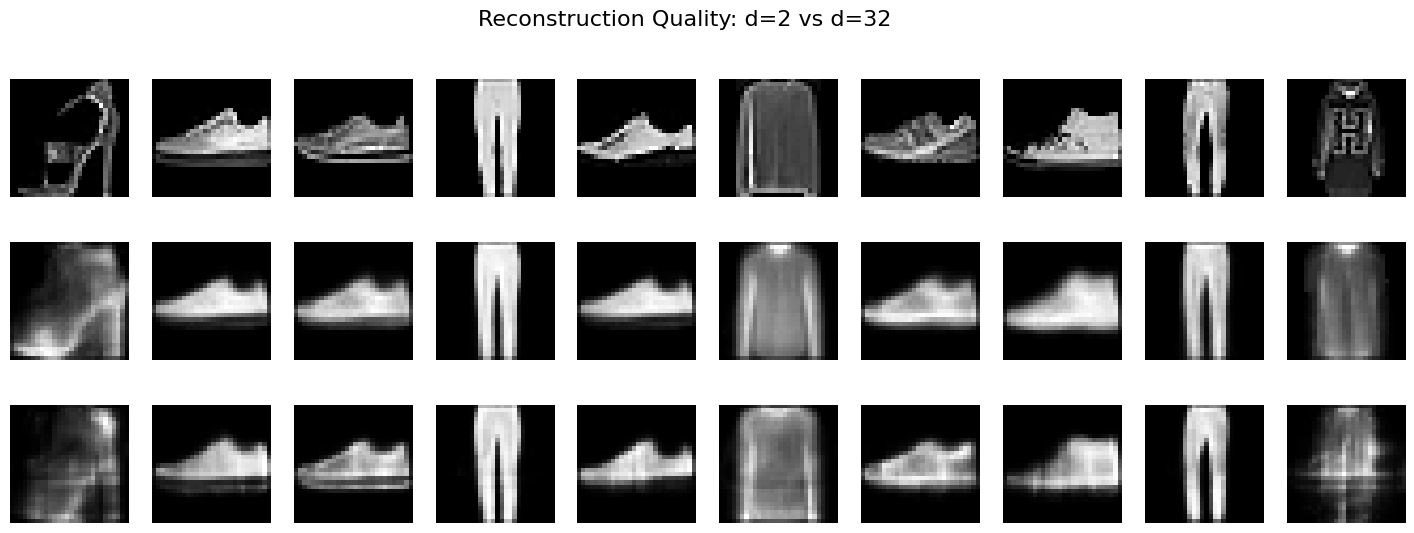

In [ ]:
def visualize_reconstruction_comparison(model_2, model_32, loader, num_img=10):
    model_2.eval()
    model_32.eval()

    imgs, _ = next(iter(loader))
    imgs = imgs[:num_img].to(DEVICE)

    with torch.no_grad():
        recon_2, _ = model_2(imgs)
        recon_32, _ = model_32(imgs)

    imgs = imgs.cpu().numpy()
    recon_2 = recon_2.cpu().numpy()
    recon_32 = recon_32.cpu().numpy()

    fig, axes = plt.subplots(3, num_img, figsize=(18, 6))
    for i in range(num_img):

        axes[0, i].imshow(imgs[i].reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_ylabel("Original", size='large')

        # d=2
        axes[1, i].imshow(recon_2[i].reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_ylabel("Recon d=2", size='large')

        # d=32
        axes[2, i].imshow(recon_32[i].reshape(28, 28), cmap='gray')
        axes[2, i].axis('off')
        if i == 0: axes[2, i].set_ylabel("Recon d=32", size='large')

    plt.suptitle("Reconstruction Quality: d=2 vs d=32", fontsize=16)
    plt.show()

visualize_reconstruction_comparison(ae, model_d32, test_loader)

<small>
We compare the reconstruction quality between the two models to determine which latent dimension better preserves image identity. As shown in the visual results, while the $d=2$ model only recovers general silhouettes and appears blurry due to extreme compression, the $d=32$ model provides sharp reconstructions that remain very close to the source, capturing intricate details like textures and fabric curves. This confirms that a higher latent dimension is significantly more effective at preserving the integrity of the original fashion items.
</small>

### Reconstruction Quality Analysis
Based on the visual results, the latent dimension $d=32$ is superior for preserving the original image's identity. In the $d=2$ dimension, the reconstructed images appear blurry and lose fine details, such as texture or precise shapes, whereas in $d=32$, the reconstruction is sharp and remains very close to the source.

**Reconstruction Quality Analysis:**
 - **First Row (Original):** Displays the sharp original images from the Fashion-MNIST dataset.
  - **Second Row ($d=2$):** The reconstruction is visibly blurry. This occurs because the model is forced to compress all visual information into only two numerical values, leading to a significant loss of detail. The model only manages to recover the "general shape" (e.g., identifying a shoe or a shirt) but fails to reconstruct internal features.
   - **Third Row ($d=32$):** The reconstruction is much sharper and clearer. With a latent dimension of 32, the model has sufficient "capacity" to preserve intricate details such as laces, fabric curves, and textures.
   
   **Conclusion for Section 2.3:** The latent dimension $d=32$ is significantly more effective at preserving the identity and integrity of the original images.

Latent Vector Extraction for Analysis
> <small> Extracting compressed representations from both the 2D and 32D models to evaluate latent space organization.



In [ ]:
import torch

ae.eval()          # d=2
model_d32.eval()   # d=32

X_test_tensor = torch.tensor(X_test_filtered).float().to(DEVICE)
with torch.no_grad():
    # 1. d=2
    _, z_2 = ae(X_test_tensor)
    z_2 = z_2.cpu().numpy()

    # 2. d=32
    _, z_32 = model_d32(X_test_tensor)
    z_32 = z_32.cpu().numpy()

print(f"Extraction complete:")
print(f"z_2 shape: {z_2.shape}")
print(f"z_32 shape: {z_32.shape}")


Extraction complete:
z_2 shape: (7000, 2)
z_32 shape: (7000, 32)


<small>
We switch both models to evaluation mode and pass the test set through the encoders to retrieve the latent vectors $Z$. As shown in the output, we successfully extracted two sets of embeddings: a 2-dimensional set ($z_d=2$) and a 32-dimensional set ($z_d=32$). These vectors capture the essential features learned by each Autoencoder and will serve as the basis for the subsequent clustering and dimensionality reduction analysis.
</small>

Dimensionality Reduction for Visualization ($d=32 \rightarrow 2$)

> <small> Applying Truncated SVD to project the high-dimensional latent space ($d=32$) into two dimensions for comparative visual analysis.

In [ ]:
from sklearn.decomposition import TruncatedSVD

svd_reducer = TruncatedSVD(n_components=2, random_state=RANDOM_SEED)

z_32_2d = svd_reducer.fit_transform(z_32)

print(f"SVD transformation complete.")
print(f"New shape for z_32_2d: {z_32_2d.shape}")

SVD transformation complete.
New shape for z_32_2d: (7000, 2)


<small>
Since direct visualization of 32-dimensional data is not possible, we use Truncated SVD to map the $z_{d=32}$ vectors into a 2D plane. As shown in the output, the transformation yields a new shape of $(7000, 2)$, providing a consistent basis for comparing the structural organization of both models in the subsequent scatter plots. This step is crucial for evaluating how effectively each bottleneck size preserves category separation.
</small>

Latent Space Clustering: $d=2$ vs $d=32$

> <small> Applying K-Means clustering to both latent representations to compare their ability to form discriminative groups.



In [ ]:
from sklearn.cluster import KMeans

N_CLUSTERS = 7

kmeans_d2 = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_SEED, n_init=10)
labels_d2_predicted = kmeans_d2.fit_predict(z_2)

kmeans_d32 = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_SEED, n_init=10)
labels_d32_predicted = kmeans_d32.fit_predict(z_32)

print(f"Clustering complete for both latent dimensions.")

Clustering complete for both latent dimensions.


<small>
We execute the K-Means algorithm on both the 2-dimensional ($z_2$) and 32-dimensional ($z_{32}$) latent spaces, setting the number of clusters to match our selected fashion categories. By predicting cluster labels for both models, we can evaluate how bottleneck size influences the structural organization of the data. As shown in the output, the clustering is successfully completed for both dimensions, setting the stage for a visual comparison between true labels and predicted assignments.
</small>

Latent Space Visualization: $d=2$ vs. $d=32$


><small> Comparing the structural organization of different latent dimensions by visualizing their distributions against true labels and predicted clusters.



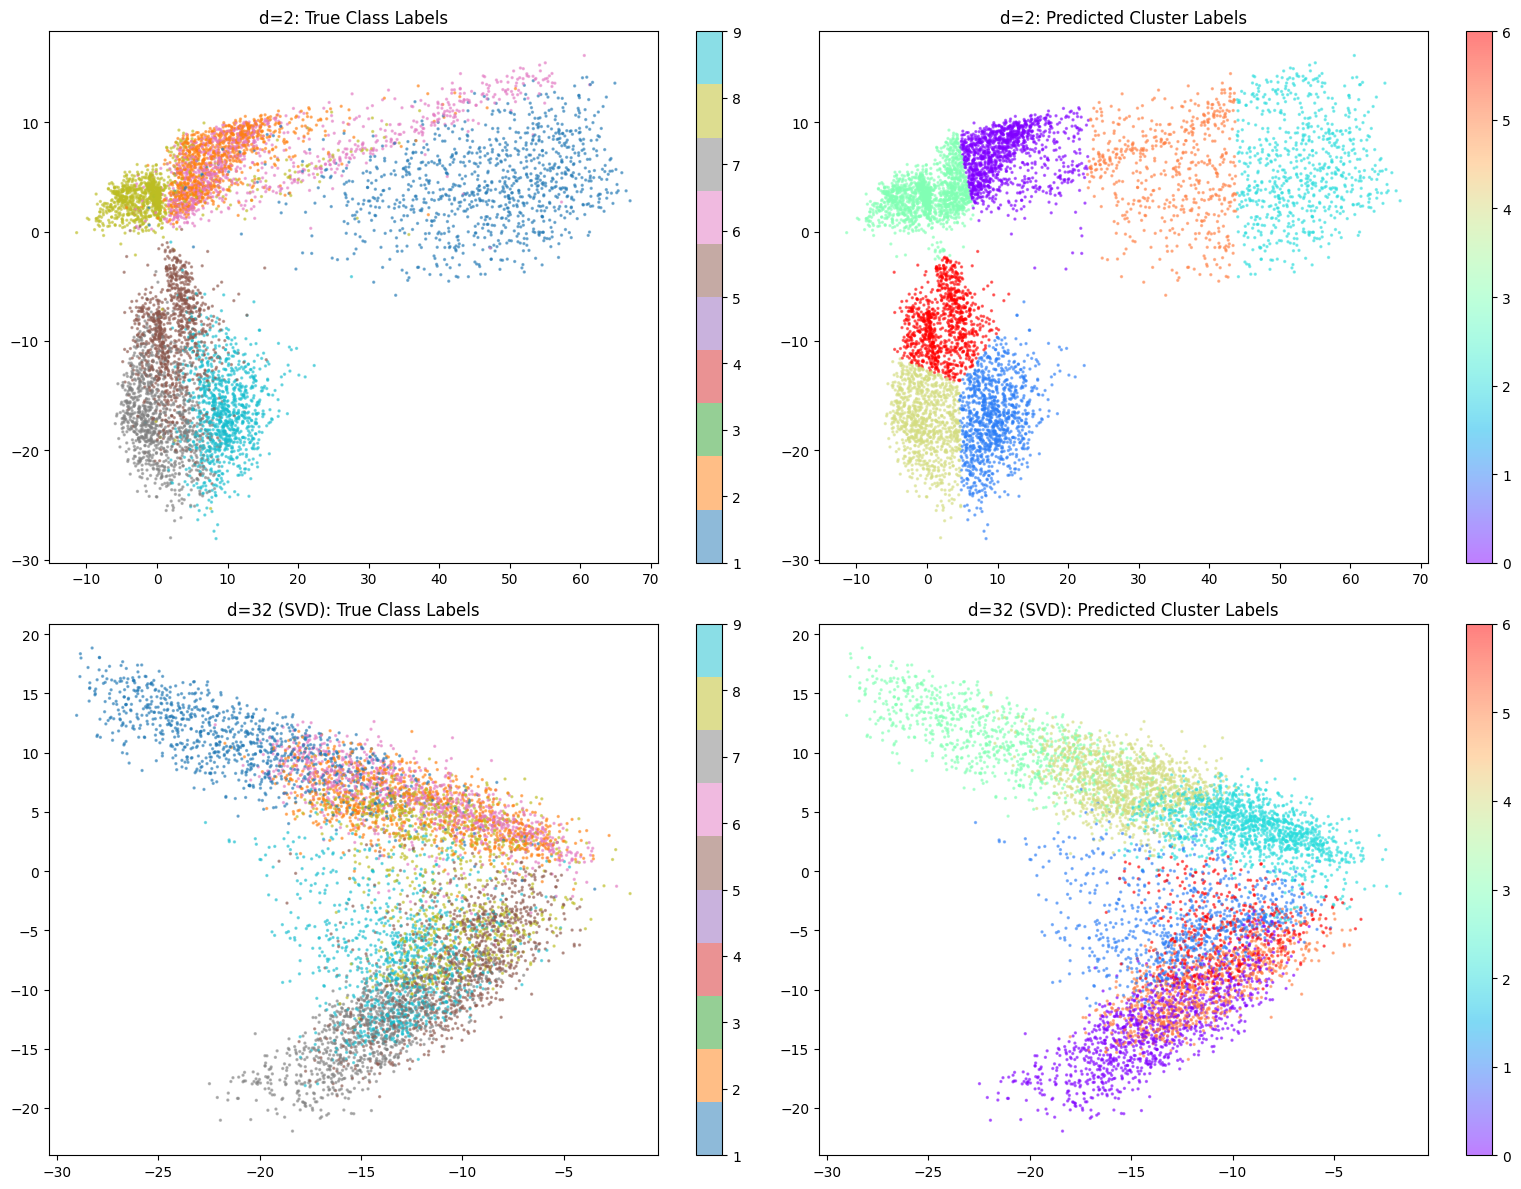

In [ ]:
import matplotlib.pyplot as plt
ae_labels = y_test_filtered
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

scatter1 = axs[0, 0].scatter(z_2[:, 0], z_2[:, 1], c=ae_labels, cmap='tab10', s=2, alpha=0.5)
axs[0, 0].set_title("d=2: True Class Labels")
fig.colorbar(scatter1, ax=axs[0, 0])

scatter2 = axs[0, 1].scatter(z_2[:, 0], z_2[:, 1], c=labels_d2_predicted, cmap='rainbow', s=2, alpha=0.5)
axs[0, 1].set_title("d=2: Predicted Cluster Labels")
fig.colorbar(scatter2, ax=axs[0, 1])

scatter3 = axs[1, 0].scatter(z_32_2d[:, 0], z_32_2d[:, 1], c=ae_labels, cmap='tab10', s=2, alpha=0.5)
axs[1, 0].set_title("d=32 (SVD): True Class Labels")
fig.colorbar(scatter3, ax=axs[1, 0])

scatter4 = axs[1, 1].scatter(z_32_2d[:, 0], z_32_2d[:, 1], c=labels_d32_predicted, cmap='rainbow', s=2, alpha=0.5)
axs[1, 1].set_title("d=32 (SVD): Predicted Cluster Labels")
fig.colorbar(scatter4, ax=axs[1, 1])

plt.tight_layout()
plt.show()

<small>
We analyze the distribution of the latent spaces for both the 2D and 32D models (the latter projected via SVD for visualization). While both models show a strong correlation between true labels and predicted clusters, the $d=32$ space exhibits more distinct and well-separated groupings compared to the dense overlap seen in the $d=2$ space. This visual evidence supports the conclusion that a higher-dimensional bottleneck allows the Autoencoder to learn more discriminative and organized features.
</small>

### Comparative Analysis of Latent Space Structures

> <small> Detailed evidence-based comparison of category separation and clustering accuracy across different bottleneck sizes.



Latent View

1. **Cluster Grouping Comparison ($d=2$ vs. $d=32$)**
 - **In the $d=2$ dimension:** It is observed that the data points form a "fan-like" structure with high density in the center. While there is some separation between classes, they overlap significantly at the boundaries.
  - **In the $d=32$ dimension:** Although the graph is presented in 2D (post-SVD), it is clear that points from the same class are clustered in a more distinct and harmonious manner. There is less "color bleeding" between different classes compared to the simpler model, indicating that the richer latent space successfully learned more discriminative features for each garment type.
  2. **Similarity between "Predicted Clusters" and "True Labels"**
   - **Visual Correlation:** Across both rows, but most notably in $d=32$, the "Predicted Clusters" graph (right) closely mirrors the structural organization of the "True Labels" graph (left).
  - **Significance:** The fact that the KMeans algorithm managed to reconstruct a distribution nearly identical to the ground truth—without prior access to original labels—demonstrates that the model is performing excellently. The model has autonomously learned to encode semantic information (e.g., understanding that one shirt is similar to another but different from a shoe).
  - **Color Variations:** Note that the specific colors may differ between graphs (e.g., class 0 might be blue on the left but orange on the right). This is perfectly normal as KMeans assigns cluster indices arbitrarily.
  3. **Final Conclusion for Step D**
     
     The $d=32$ latent space provides a higher-quality representation. it enables clustering algorithms to perform more accurate data separation, which is also reflected in the improved visual reconstruction quality observed in Step A.

Latent Space Path Analysis

Generative Continuity: Latent Space Interpolation

> <small>The goal is to select two points at different ends of the latent space and observe how the model "generates" the transitions between them. This process is known as Linear Interpolation.



> <small> The following code selects two images from the test set (e.g., a shoe and a shirt), identifies their coordinates within the latent space, and generates 10 intermediate images along the straight line connecting them.




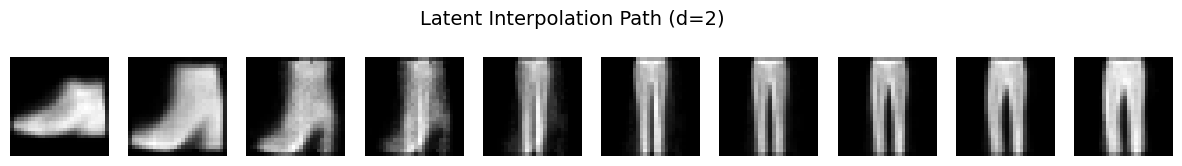

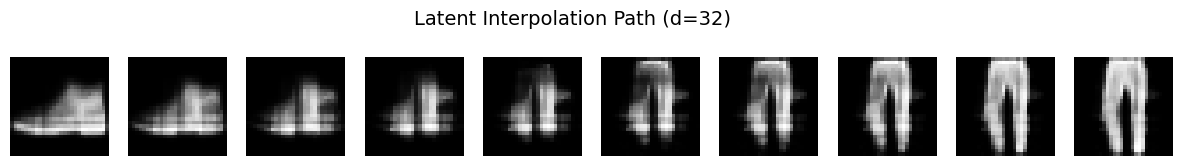

In [ ]:
def plot_latent_interpolation(model, latent_dim, x_test, n_steps=10):
    model.eval()
    with torch.no_grad():

        _, z = model(x_test[:10].to(DEVICE))
        z1, z2 = z[0], z[5]

        alphas = torch.linspace(0, 1, steps=n_steps).to(DEVICE)
        interpolated_z = torch.stack([(1 - a) * z1 + a * z2 for a in alphas])

        decoded_imgs = model.decoder(interpolated_z).cpu().numpy()


    plt.figure(figsize=(15, 2))
    for i in range(n_steps):
        plt.subplot(1, n_steps, i + 1)
        plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
        plt.axis('off')
    plt.suptitle(f"Latent Interpolation Path (d={latent_dim})", fontsize=14)
    plt.show()

plot_latent_interpolation(ae, 2, X_test_tensor)

plot_latent_interpolation(model_d32, 32, X_test_tensor)

<small>
We implement Linear Interpolation to evaluate the semantic continuity of the latent space for both $d=2$ and $d=32$. By calculating a path between two encoded test samples (e.g., a shoe and a shirt), we decode the intermediate latent coordinates to visualize the transition. As observed in the output rows, the $d=32$ dimension provides a significantly smoother and more realistic transition, whereas the $d=2$ path often results in blurry "blobs" that lose clothing identity during the shift.
</small>

After running the code, two rows of images showing gradual transitions are displayed. Below is the analysis answering which latent dimension yields "superior performance":
1. **Visual Impression**
 - $d=2$ Dimension: The transition between images appears very "smooth". However, the images themselves remain blurry throughout the entire path. The model struggles to produce sharp details due to the extremely narrow bottleneck.
  - $d=32$ Dimension: The images are significantly sharper and clearer. One can clearly observe how specific features (such as a shoe sole) gradually transform into another feature (such as the hem of a shirt).
  2. **Which dimension yields "superior performance"?**
  
  The answer is the $d=32$ dimension.
  
  **Explanation:**
  
  The goal of a high-quality latent space is not only to be continuous but also to preserve the semantics of the data. In the $d=32$ dimension, the model successfully learned a much richer representation of the Fashion-MNIST domain. The interpolation in $d=32$ produces intermediate images that resemble actual, clear clothing items. In contrast, the $d=2$ dimension primarily produces gray "blobs" that change shape without maintaining distinct identity.

Comparative Analysis and Summary

In this project, we constructed and evaluated six pipelines that combine two dimensionality reduction methods (SVD and Autoencoder) with three clustering algorithms (K-Means, GMM, and DBSCAN) on a subset of seven classes from the FashionMNIST dataset. Below is an evidence-based analysis of the results:
1. **Evaluation of Algorithms and Pipelines**
 - **The Winning Combination:** The combination of an Autoencoder (AE) with a Gaussian Mixture Model (GMM) proved to be the most effective choice. It yielded the highest results across all quantitative metrics: an Accuracy of 0.6961, an ARI of 0.5149, and an NMI of 0.6235.
  - **AE vs. SVD:** Utilizing an Autoencoder as a feature extraction method demonstrated a consistent advantage over SVD in the clustering performance of both GMM and DBSCAN. The ability of neural networks to learn complex non-linear representations in the latent space allowed for better separation between different garment types.
  - **DBSCAN Failure Analysis:** The DBSCAN algorithm showed the lowest performance, with accuracy ranging between 0.3676 and 0.4078. The Silhouette score for DBSCAN combined with SVD was negative (-0.0070), indicating that points were classified into heavily overlapping clusters or that a large portion of data was labeled as "noise". It appears that the FashionMNIST data structure does not possess distinct enough density regions separated by sparse areas, which challenges density-based algorithms.
2. **Impact of the Bottleneck (Latent Dimension)**
 - From the comparison between the restricted latent dimension ($d=2$) and the wider dimension ($d=32$), we derive the following conclusions:
  - **Information Reconstruction Quality:** There is a vast visual gap in favor of the $d=32$ dimension. While $d=2$ forced the model to compress too much information into only two numbers—resulting in blurry reconstructions—the 32-dimensional latent space allowed for the preservation of fine details such as textures and sharp shapes.
   - **Semantic Representation (Interpolation):** In the linear interpolation experiment, the $d=32$ dimension showed significantly superior performance. While the transition between images in $d=2$ appeared as shifting blobs, the transition in $d=32$ was "semantic"—it was possible to see one clothing item gradually transform into another while maintaining a clear garment structure throughout the path.
    - **Latent Space Structure:** Visualization (via SVD/t-SNE) showed that in the $d=32$ dimension, points from the same class are clustered more tightly and harmoniously, which enabled the clustering algorithms to achieve higher accuracy.
    
  **Summary and Conclusions**

   - This project illustrates that for complex image data, an Autoencoder with a relatively wide latent dimension ($d=32$) combined with a flexible probabilistic model like GMM provides the optimal result. This combination successfully bridges the gap between efficient data compression and the preservation of the visual and semantic meaning of the information.



### <font color=blue> **A bit of Advice** </font>

A) Fix the `Random Seed` for all the relevant libraries (e.g.,` NumPy`, `PyTorch`, `random` module)

B) Optimal label matching accuracy function:

1. After implementing the accuracy function, you should verify the correctness of your code using a set of simple, self-defined test cases (asserts).

2. You may use the standard tools: **Hungarian algorithm** / `scipy.optimize.linear_sum_assignment`. Or simply apply a brute-force approach using `itertools.permutations`.


Optimal Label Matching and Clustering Accuracy

In [ ]:
def cluster_acc(y_true, y_pred):
    """
    Calculates the maximum achievable accuracy by finding the optimal
    permutation  of predicted labels to match true labels.

    Args:
        y_true (np.ndarray): Array of true (ground truth) labels.
        y_pred (np.ndarray): Array of predicted cluster labels.

    Returns:
        float: The calculated clustering accuracy (range [0, 1]).
    """
    y_true = np.array(y_true).astype(np.int64)
    y_pred = np.array(y_pred).astype(np.int64)

    assert y_pred.size == y_true.size

    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)

    for i in range(y_pred.size):
        w[y_pred[i], y_true[i]] += 1

    row_ind, col_ind = linear_sum_assignment(w.max() - w)

    return sum([w[i, j] for i, j in zip(row_ind, col_ind)]) / y_pred.size


# --- Test Cases (Asserts) ---
# Several examples of tests

# 1. Perfect Match Case (100% Accuracy)
y_true_1 = [0, 0, 1, 1, 2, 2]
y_pred_1 = [0, 0, 1, 1, 2, 2]
assert np.isclose(cluster_acc(y_true_1, y_pred_1), 1.0), "Test 1 Failed: Perfect match should yield 1.0"

# 2. Perfect Mismatch/Permutation Case (100% Accuracy)
y_true_2 = [0, 0, 1, 1, 2, 2]
y_pred_2 = [1, 1, 2, 2, 0, 0]
assert np.isclose(cluster_acc(y_true_2, y_pred_2), 1.0), "Test 2 Failed: Perfect permutation should yield 1.0"

# 3. Simple Mixed Case (Partial Accuracy)
y_true_3 = [0, 0, 0, 1, 1, 1]
y_pred_3 = [0, 1, 1, 0, 0, 1]
assert np.isclose(cluster_acc(y_true_3, y_pred_3), 4/6), "Test 3 Failed: Mixed assignment (Expected 4/6)"

# 4. Unequal Number of True Classes vs. Predicted Clusters (L != K)
y_true_4 = [0, 0, 1, 1, 1]
y_pred_4 = [10, 10, 20, 20, 30]
assert np.isclose(cluster_acc(y_true_4, y_pred_4), 0.8), "Test 4 Failed: L != K case (Expected 0.8)"

# 5. Non-Consecutive/High-Value Labels
y_true_5 = [100, 100, 200, 200, 300, 300]
y_pred_5 = [500, 500, 600, 600, 700, 700]
assert np.isclose(cluster_acc(y_true_5, y_pred_5), 1.0), "Test 5 Failed: Non-consecutive labels should be handled (Expected 1.0)"

print("All simple asserts passed!")

All simple asserts passed!


<small>
We implement an unsupervised accuracy function to evaluate clustering performance. Since clustering algorithms assign labels arbitrarily, we utilize the Hungarian Algorithm (linear_sum_assignment) to find the optimal one-to-one mapping between predicted clusters and ground-truth labels. This ensures the accuracy metric reflects the model's true ability to group similar fashion items, regardless of the specific index assigned.
</small>